# Protocol 5: Copy Number, Abundance and Ensemble Assembly

This notebook follows [Jirasek et al. (2026)](https://doi.org/10.48550/arXiv.2512.18752), which quantifies the emergence of selection in prebiotic peptide chemistry.

Every other protocol here stops at the assembly index of a single object. That index measures how much construction a thing required, but on its own it cannot detect selection: given enough time and material, a combinatorial process will make almost any particular structure once. What it will not do is make the same complex structure many times over. Selection shows up only when a high assembly index is paired with a high **copy number**, and the two are combined in the assembly equation.

This protocol is about that pairing — where the copy numbers come from, how they enter the equation, and how much the answer depends on the choice. It

- computes a peptide's assembly index as $a_P = a_\mathrm{JAS} + a_S$, the joint assembly index of its amino acids plus the assembly index of its sequence;
- simulates peptide formation under a copy-number-weighted polymerisation model, with and without an environmental selection pressure;
- measures both of the paper's metrics on the result, ensemble assembly $A$ and the exploration ratio;
- and then asks the question a real experiment forces: mass spectrometry measures intensity, not copy number, so which way of turning abundance into $n_i$ actually recovers the answer?

## Running it

Run this notebook from its own directory so the figures it saves land beside
it. In JupyterLab:

```bash
cd examples/protocols/5
jupyter lab protocol_5.ipynb
```

Or headlessly, which is how the committed outputs were produced:

```bash
cd examples/protocols/5
jupyter nbconvert --to notebook --execute --inplace protocol_5.ipynb
```

Use **Run All** so the total-time cell at the end measures the whole workflow.

This protocol needs no external data and no network access: the ensembles are simulated below. The paper's own experimental peptide data is not publicly available, so the simulation stands in for it — see the note in section 4.

## Timing

The heavy steps below start with the `%%time` cell magic. Read the **Wall
time** it reports. Everything here runs on a single core, so wall time and CPU
time agree. The times shown were recorded on a 28-core machine and will differ
on yours.

In [1]:
%matplotlib inline
import contextlib
import io
import itertools
import os
import random
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display

import assemblytheorytools as att

print(f"CPU cores available: {os.cpu_count()}")
_t_start = time.perf_counter()

CPU cores available: 28


## Parameters

In [2]:
# The five amino acids used throughout the paper, as one-letter code -> SMILES.
# They are small, water soluble, and have distinguishable exact masses.
AMINO_ACIDS = {
    'G': 'C(C(=O)O)N',                 # glycine
    'A': 'C[C@@H](C(=O)O)N',           # L-alanine
    'V': 'CC(C)[C@@H](C(=O)O)N',       # L-valine
    'H': 'O=C([C@H](CC1=CNC=N1)N)O',   # L-histidine
    'P': 'C1C[C@H](NC1)C(=O)O',        # L-proline
}

# The peptide drawn in Figure 2b of the paper.
EXAMPLE_PEPTIDE = 'GGGAPPHVPHVHHPVGGG'

# Per-search timeout for the molecular calculation, in seconds. In exact mode
# a search that exceeds this returns a negative value rather than an upper
# bound, and we treat that as a failure below.
TIMEOUT = 5.0 * 60.0

# Polymerisation simulation. Each monomer starts with MONOMER_COPIES copies and
# the run takes N_STEPS combination steps, keeping the paper's one-to-one ratio
# between the two.
N_STEPS = 20_000
MONOMER_COPIES = 20_000
MAX_LENGTH = 12        # products longer than this are discarded
N_REPEATS = 3          # independent runs per regime, for error bars
SEED = 1

# The environmental selection pressure imposed in the directed runs: sequences
# ending in this residue are this many times more likely to react.
SELECTION_RESIDUE = 'V'
SELECTION_FACTOR = 100.0

# Synthetic detection model for section 8. Each species is given a log-normal
# ionisation response factor of this spread, and anything whose resulting
# intensity falls below the floor is treated as undetected.
RESPONSE_SIGMA = 1.0
RESPONSE_SIGMAS = (0.25, 0.5, 1.0, 2.0, 3.0)
DETECTION_FLOOR = 1.0
EQUAL_COPY_NUMBER = 100.0   # the copy number the paper assigns every detection
N_DRAWS = 30                # independent response draws, for the spread of A
RESPONSE_SEED = 7

# The ways of turning an observed intensity back into a copy number that
# section 8 compares, the first being the ground truth a real experiment
# does not have.
SCHEMES = ('true copy number', 'equal per detection',
           'intensity-proportional', 'log-scaled intensity')

## Part A: what goes into the equation

### 1. The building blocks

Assembly theory measures an object against the units it is built from. For a peptide those units are amino acids, but the amino acids are themselves molecules that had to be constructed, and the paper accounts for that cost separately.

$a_\mathrm{JAS}$ is the *joint* assembly index of the amino acid set: the number of bond-forming steps needed to build all five together, sharing every intermediate they have in common. `att.join_graphs` merges the five molecular graphs into one disconnected graph, and `att.calculate_assembly_index` on that graph returns the joint index. This reproduces Figure 2a of the paper, and is the same calculation Protocol 1 performs.

In [3]:
%%time
graphs = [att.smi_to_nx(smi) for smi in AMINO_ACIDS.values()]

a_jas, virt_obj, _ = att.calculate_assembly_index(
    att.join_graphs(graphs),
    strip_hydrogen=True,
    timeout=TIMEOUT,
    exact=True,
)
if a_jas < 0:
    raise RuntimeError("The joint assembly search timed out before finding an exact result")

print(f"Building blocks: {', '.join(AMINO_ACIDS)}")
print(f"Joint assembly index of the five amino acids, a_JAS = {a_jas}")
print(f"Shared intermediates along the joint pathway: {len(virt_obj)}")

Building blocks: G, A, V, H, P
Joint assembly index of the five amino acids, a_JAS = 12
Shared intermediates along the joint pathway: 18
CPU times: user 7.32 ms, sys: 1.01 ms, total: 8.32 ms
Wall time: 26 ms


### 2. The assembly index of a peptide

With the amino acids paid for, a peptide is treated modularly: a string over a five-letter alphabet, where a join concatenates two pieces that already exist. Its total assembly index is

$$a_P = a_\mathrm{JAS} + a_S$$

where $a_S$ is the string assembly index of the sequence.

`att.calculate_string_assembly_index` computes $a_S$. Two of its modes matter here. `mode='str'` runs the exact search. `mode='cfg'` returns a context-free-grammar construction instead: an upper bound on the index, but delivered with a pathway whose nodes *are* the substrings they stand for, which is what makes the joint assembly spaces of section 5 composable. Sequences are lowercased because that backend accepts lowercase ASCII only.

In [4]:
sequence = EXAMPLE_PEPTIDE.lower()

# The exact backend prints a diagnostic when it cannot also report a pathway.
# The index it returns is unaffected, and the pathway comes from cfg below.
buffer = io.StringIO()
with contextlib.redirect_stdout(buffer):
    a_s = att.calculate_string_assembly_index(sequence, mode='str')[0]

_, _, pathway = att.calculate_string_assembly_index(sequence, mode='cfg')

print(f"Peptide: {EXAMPLE_PEPTIDE}  ({len(EXAMPLE_PEPTIDE)} residues)")
print(f"    string assembly index   a_S = {a_s}")
print(f"    peptide assembly index  a_P = a_JAS + a_S = {a_jas} + {a_s} = {a_jas + a_s}")

Peptide: GGGAPPHVPHVHHPVGGG  (18 residues)
    string assembly index   a_S = 13
    peptide assembly index  a_P = a_JAS + a_S = 12 + 13 = 25


Building the sequence residue by residue would take one join per residue after the first. The index is lower because a substring, once built, can be reused for free — which is exactly what the pathway below shows.

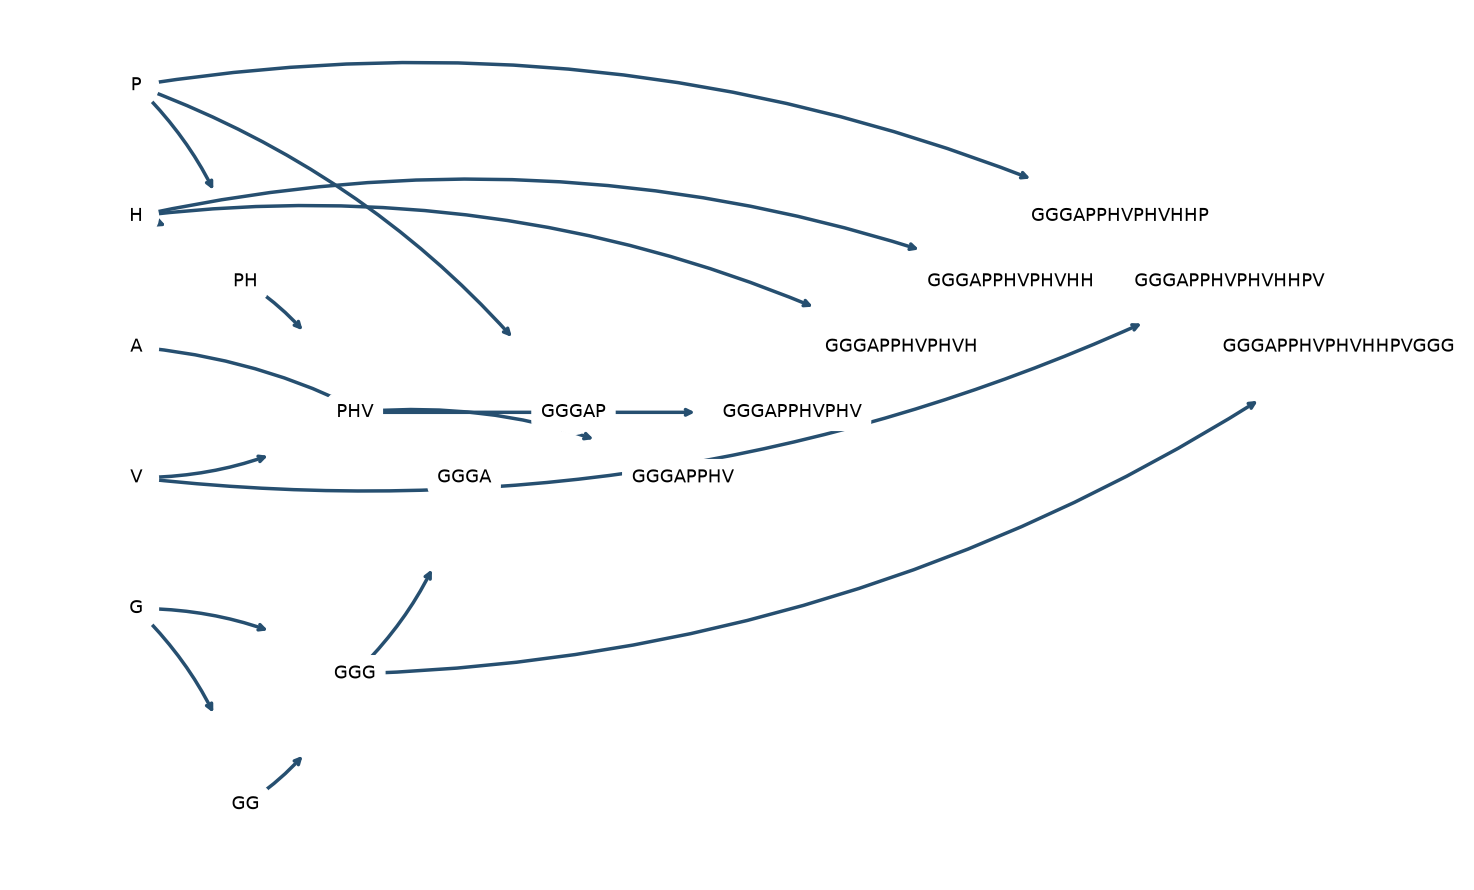

In [5]:
# plot_pathway labels each node from its 'vo' attribute. In a string pathway
# the node identifier already is the substring it stands for, so copy it
# across, upper-cased back into one-letter residue codes.
nx.set_node_attributes(pathway, {n: n.upper() for n in pathway.nodes}, 'vo')

fig, ax = att.plot_pathway(
    pathway,
    plot_type='string',
    font_size=13,
    fig_size=(15, 9),
    layout_style='crossmin_long',
)
plt.savefig("peptide_pathway.png", dpi=300)
plt.savefig("peptide_pathway.svg")
plt.show()

*The assembly pathway of the peptide GGGAPPHVPHVHHPVGGG, treating amino acids as units, reproducing Figure 2b of the paper. The reused substrings appear as shared intermediates.*

### 3. The assembly equation

The index alone says nothing about selection. It has to be paired with copy number, and the two combine in the assembly equation. ATT implements the form given by Sharma *et al.* (2023),

$$A = \sum_{i=1}^{N} e^{a_i}\left(\frac{n_i - 1}{N_\mathrm{T}}\right)$$

while equation (1) of the paper writes it as

$$A = \sum_{i \in n_i > 1}^{N} e^{a_i}\left(\frac{n_i}{N_\mathrm{T}}\right)$$

with $N$ unique objects, $n_i$ the copy number of object $i$, and $N_\mathrm{T}$ the total. The exponential makes assembly grow sharply with index; dividing by $N_\mathrm{T}$ lets ensembles of different sizes be compared. The two forms differ only in how they discard objects seen once: the first through the $n_i - 1$ factor, which makes a singleton's term vanish, the second through the summation range. They agree to a factor $1 - 1/n_i$, so they converge as copy numbers grow.

`att.calculate_assembly_from_indices` evaluates the first form from indices that are already known, which is what a composite index like $a_P$ requires. The second is four lines, below.

In [6]:
def assembly_paper(ai_list, n_i):
    """Evaluate equation (1) of the paper: singletons dropped, weight n_i / N_T."""
    n_t = sum(n_i)
    return float(sum(np.exp(a) * (n / n_t)
                     for a, n in zip(ai_list, n_i) if n > 1))


# Ethanol and caffeine, the worked example from the ATT theory page.
demo_ai = [1, 9]

rows = []
for copies in (2, 5, 10, 100, 1_000):
    n_i = [float(copies)] * len(demo_ai)
    a_att = att.calculate_assembly_from_indices(demo_ai, n_i)
    a_paper = assembly_paper(demo_ai, n_i)
    rows.append({'copy number': copies, 'A (ATT)': a_att, 'A (paper)': a_paper,
                 'ratio': a_att / a_paper, '1 - 1/n': 1 - 1 / copies})

display(pd.DataFrame(rows).round(4))
print(f"mean of exp(a_i) over the unique objects: {np.mean(np.exp(demo_ai)):.4f}")

,copy number,A (ATT),A (paper),ratio,1 - 1/n
0,2,2026.4506,4052.9011,0.500,0.500
1,5,3242.3209,4052.9011,0.800,0.800
2,10,3647.6110,4052.9011,0.900,0.900
3,100,4012.3721,4052.9011,0.990,0.990
4,1000,4048.8482,4052.9011,0.999,0.999


mean of exp(a_i) over the unique objects: 4052.9011


The last two columns are the same number, and the paper's $A$ equals the mean of $e^{a_i}$ exactly. Both follow from every object having the same copy number $c$: then $N_\mathrm{T} = Nc$, the paper's form collapses to $\frac{1}{N}\sum_i e^{a_i}$, and ATT's is $(1 - 1/c)$ times it. That case is not a curiosity — it is precisely what the paper does with its mass-spectrometry data, and section 8 returns to it.

One consequence of $a_P = a_\mathrm{JAS} + a_S$ is worth stating before going further. Since $a_\mathrm{JAS}$ is a constant for a fixed set of building blocks, $e^{a_P} = e^{a_\mathrm{JAS}} e^{a_S}$, so switching from sequence-scale to peptide-scale indices multiplies $A$ by a constant:

In [7]:
print(f"exp(a_JAS) = exp({a_jas}) = {np.exp(a_jas):.3e}")
print("Ensembles over the same building blocks stay comparable; ensembles over")
print("different building blocks do not. The sections below report A on the")
print("sequence scale, which is where the paper's own values lie.")

exp(a_JAS) = exp(12) = 1.628e+05
Ensembles over the same building blocks stay comparable; ensembles over
different building blocks do not. The sections below report A on the
sequence scale, which is where the paper's own values lie.


## Part B: an ensemble with real copy numbers

### 4. A copy-number-weighted polymerisation

The paper's experiments polymerise amino acids under conditions that impose no sequence preference — heat-driven wet-dry cycling, or coupling with carbonyldiimidazole — and separately under proteases, which are molecular artefacts of biological evolution and therefore impose a *known* selection pressure. Comparing the two is what makes selection measurable rather than assumed.

Those ensembles are not publicly available, so this notebook uses the phenomenological model the paper describes alongside them. Five monomers each start with `MONOMER_COPIES` copies. At each step two sequences are drawn **weighted by their current copy numbers**, concatenated, and the product's count incremented while both parents are decremented. Copy number is thus not an afterthought: it drives the dynamics, which is the point the model is making about mass-transfer-limited chemistry.

Selection enters as an environmental effect, by multiplying the selection probability of sequences ending in one particular residue by `SELECTION_FACTOR`.

Several details are unstated in the paper and are choices made here: that a combination consumes its parents, that products above `MAX_LENGTH` are discarded, and the scale, which is reduced from $10^6$ steps to `N_STEPS` to keep the notebook quick. Treat what follows as a reimplementation that reproduces the reported behaviour, not as the paper's own numbers.

In [8]:
MONOMERS = [residue.lower() for residue in AMINO_ACIDS]


def polymerise(n_steps, seed, monomer_copies, max_length,
               selection_residue=None, selection_factor=1.0):
    """
    Grow sequences by repeatedly combining two of them, weighted by copy number.

    Parameters
    ----------
    n_steps : int
        Number of combination steps.
    seed : int
        Seed for this run's random number generator.
    monomer_copies : int
        Starting copy number of each monomer.
    max_length : int
        Products longer than this are discarded.
    selection_residue : str, optional
        When given, sequences ending in this residue are favoured.
    selection_factor : float, optional
        How much more likely a favoured sequence is to react.

    Returns
    -------
    dict
        Surviving sequences of more than one residue, and their copy numbers.
    """
    rng = random.Random(seed)
    counts = {monomer: monomer_copies for monomer in MONOMERS}
    pool = list(counts)

    for _ in range(n_steps):
        weights = [
            counts[s] * (selection_factor
                         if selection_residue and s.endswith(selection_residue)
                         else 1.0)
            for s in pool
        ]
        left, right = rng.choices(pool, weights=weights, k=2)
        product = left + right

        # Skip a step that would exceed the length cap or consume a sequence
        # that has already run out.
        if len(product) > max_length or counts[left] < 1 or counts[right] < 1:
            continue

        if product not in counts:
            counts[product] = 0
            pool.append(product)
        counts[product] += 1
        counts[left] -= 1
        counts[right] -= 1

    return {s: n for s, n in counts.items() if n > 0 and len(s) > 1}

In [9]:
%%time
REGIMES = {
    'undirected': {},
    'directed': {'selection_residue': SELECTION_RESIDUE.lower(),
                 'selection_factor': SELECTION_FACTOR},
}

ensembles = {
    regime: [polymerise(N_STEPS, SEED + i, MONOMER_COPIES, MAX_LENGTH, **kwargs)
             for i in range(N_REPEATS)]
    for regime, kwargs in REGIMES.items()
}

for regime, runs in ensembles.items():
    print(f"{regime:11} {N_REPEATS} runs, "
          f"{np.mean([len(c) for c in runs]):.0f} unique sequences each, "
          f"longest {max(len(s) for c in runs for s in c)} residues")

undirected  3 runs, 634 unique sequences each, longest 9 residues
directed    3 runs, 671 unique sequences each, longest 12 residues
CPU times: user 1.3 s, sys: 274 μs, total: 1.31 s
Wall time: 1.31 s


### 5. Assembly indices and the joint assembly space

Each unique sequence now needs two things: its assembly index, and a construction pathway.

The index comes from the exact search, `mode='str'`. The pathway comes from `mode='cfg'`, because the exact backend does not return a pathway whose nodes carry the substrings, and the joint assembly space is built by merging pathways on their shared substrings. That makes the pathway a construction of the sequence, but not always a *minimum* one, so the cell after next measures how often the two agree — which is the accuracy of the joint assembly space that follows.

In [10]:
%%time
sequences = sorted({s for runs in ensembles.values() for counts in runs for s in counts})

# The str backend prints a diagnostic when a sequence has no reusable
# substructure to report a pathway for; the index it returns is unaffected.
buffer = io.StringIO()
with contextlib.redirect_stdout(buffer):
    index_of = {s: att.calculate_string_assembly_index(s, mode='str')[0]
                for s in sequences}

pathway_of = {s: att.calculate_string_assembly_index(s, mode='cfg')[2]
              for s in sequences}
bound_of = {s: att.calculate_string_assembly_index(s, mode='cfg')[0]
            for s in sequences}

print(f"Unique sequences across all {len(ensembles) * N_REPEATS} runs: {len(sequences)}")
print(f"Assembly index a_S ranges from {min(index_of.values())} to {max(index_of.values())}")

Unique sequences across all 6 runs: 2245
Assembly index a_S ranges from 1 to 9
CPU times: user 2.2 s, sys: 363 ms, total: 2.56 s
Wall time: 3.45 s


In [11]:
exact = [s for s in sequences if bound_of[s] == index_of[s]]
overshoot = [bound_of[s] - index_of[s] for s in sequences]

print(f"Pathways that are minimum: {len(exact)} of {len(sequences)} "
      f"({len(exact) / len(sequences):.1%})")
print(f"Largest overshoot on the rest: {max(overshoot)} steps")
print()
print("The joint assembly space below is therefore a slight over-approximation:")
print("a few percent of sequences contribute an intermediate or two more than")
print("a minimum construction would. Exploration ratios are correspondingly a")
print("little low, equally so in both regimes.")

Pathways that are minimum: 2184 of 2245 (97.3%)
Largest overshoot on the rest: 2 steps

The joint assembly space below is therefore a slight over-approximation:
a few percent of sequences contribute an intermediate or two more than
a minimum construction would. Exploration ratios are correspondingly a
little low, equally so in both regimes.


The joint assembly space is the union of those pathways, sharing every substring that more than one sequence needs. Its nodes are the sequences that were observed together with the *contingent* ones — intermediates a construction requires but which were never themselves produced in quantity. The exploration ratio is the first divided by the total.

`att.exploration_ratio` infers the observed set from each pathway's target by default. That is not right here: this ensemble observes many of its own intermediates, because a sequence that was made can be used to make a longer one. Passing `observed` explicitly is what makes the ratio measure what the paper means by it.

In [12]:
def summarise(counts):
    """Measure one run: its diversity, exploration ratio and assembly."""
    seqs = list(counts)
    pathways = [pathway_of[s] for s in seqs]

    return {
        'diversity': len(seqs),
        'exploration ratio': att.exploration_ratio(pathways, observed=seqs),
        'A': att.calculate_assembly_from_indices([index_of[s] for s in seqs],
                                                 [counts[s] for s in seqs]),
        'A (paper eq. 1)': assembly_paper([index_of[s] for s in seqs],
                                          [counts[s] for s in seqs]),
        'max index': max(index_of[s] for s in seqs),
        'mean length': float(np.mean([len(s) for s in seqs])),
    }


runs = pd.DataFrame([
    {'regime': regime, 'run': i, **summarise(counts)}
    for regime, ensemble in ensembles.items()
    for i, counts in enumerate(ensemble)
])
display(runs.round(3))

,regime,run,diversity,exploration ratio,A,A (paper eq. 1),max index,mean length
0,undirected,0,638,0.891,3.512,3.746,7,3.983
1,undirected,1,630,0.895,3.485,3.695,7,3.965
2,undirected,2,635,0.896,3.508,3.738,6,3.978
3,directed,0,683,0.667,31.226,38.801,9,8.028
4,directed,1,669,0.697,35.796,44.504,8,8.073
5,directed,2,660,0.690,33.630,41.790,9,8.085


### 6. Exploration ratio and assembly

Averaged over the repeats, the two regimes separate on both metrics.

In [13]:
summary = runs.groupby('regime')[['diversity', 'exploration ratio', 'A',
                                  'A (paper eq. 1)', 'max index']].agg(['mean', 'std'])
display(summary.round(3))

er = runs.groupby('regime')['exploration ratio'].mean()
assembly = runs.groupby('regime')['A'].mean()
print(f"Exploration ratio falls by {er['undirected'] - er['directed']:.2f} "
      f"under selection, while A rises {assembly['directed'] / assembly['undirected']:.0f}-fold.")
print("The paper reports 0.85-0.95 without selection and 0.51-0.75 with it.")

diversity         exploration ratio              A         \
                mean     std              mean    std    mean    std   
regime                                                                 
directed     670.667  11.590             0.685  0.016  33.550  2.286   
undirected   634.333   4.041             0.894  0.002   3.502  0.014   

           A (paper eq. 1)        max index         
                      mean    std      mean    std  
regime                                              
directed            41.698  2.853     8.667  0.577  
undirected           3.726  0.027     6.667  0.577

Exploration ratio falls by 0.21 under selection, while A rises 10-fold.
The paper reports 0.85-0.95 without selection and 0.51-0.75 with it.


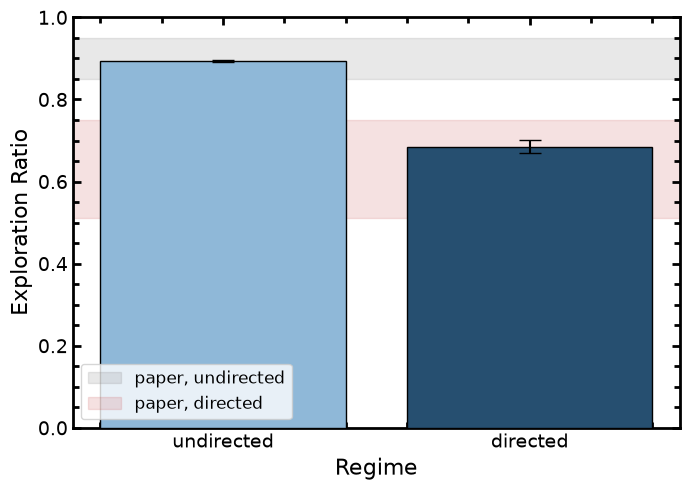

In [14]:
order = list(ensembles)
means = [runs.loc[runs['regime'] == r, 'exploration ratio'].mean() for r in order]
errors = [runs.loc[runs['regime'] == r, 'exploration ratio'].std() for r in order]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(order, means, yerr=errors, capsize=8, color=['#8fb8d8', '#264f70'],
       edgecolor='black', zorder=3)
ax.axhspan(0.85, 0.95, color='grey', alpha=0.18, zorder=1,
           label='paper, undirected')
ax.axhspan(0.51, 0.75, color='indianred', alpha=0.18, zorder=1,
           label='paper, directed')
ax.set_ylim(0, 1)
ax.legend(fontsize=12, loc='lower left')
att.ax_plot(fig, ax, "Regime", "Exploration Ratio", xs=16, ys=16)
plt.savefig("exploration_ratio.png", dpi=300)
plt.savefig("exploration_ratio.svg")
plt.show()

*Exploration ratio of the simulated ensembles, with error bars over the repeat runs, against the ranges the paper reports for undirected and protease-directed peptide formation.*

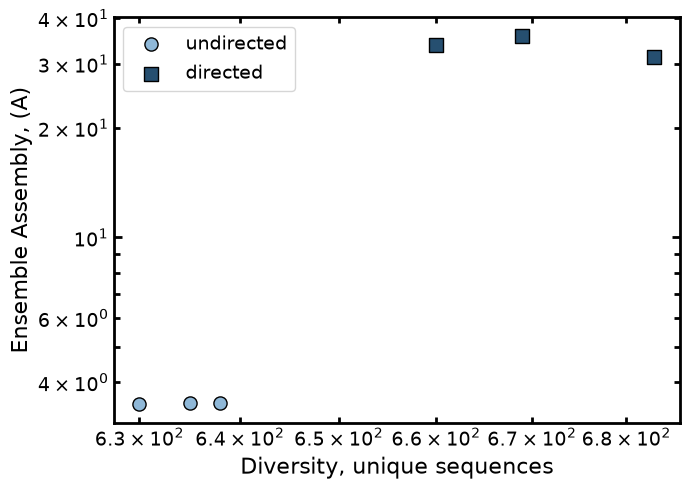

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
for regime, marker, colour in zip(order, ('o', 's'), ('#8fb8d8', '#264f70')):
    subset = runs[runs['regime'] == regime]
    ax.scatter(subset['diversity'], subset['A'], s=90, marker=marker,
               color=colour, edgecolor='black', label=regime, zorder=3)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=14)
att.ax_plot(fig, ax, "Diversity, unique sequences", "Ensemble Assembly, (A)",
            xs=16, ys=16)
plt.savefig("assembly_vs_diversity.png", dpi=300)
plt.savefig("assembly_vs_diversity.svg")
plt.show()

*Ensemble assembly against diversity for every run, as in Figure 5g and 5h of the paper. At comparable numbers of unique sequences the directed ensembles carry an order of magnitude more assembly.*

### 7. What the two ensembles look like

The separation above comes from a difference in the shape of the two ensembles. Selection produces longer and more repetitive sequences, so their assembly indices spread further from the diagonal that unbroken, unrepeated sequences would follow.

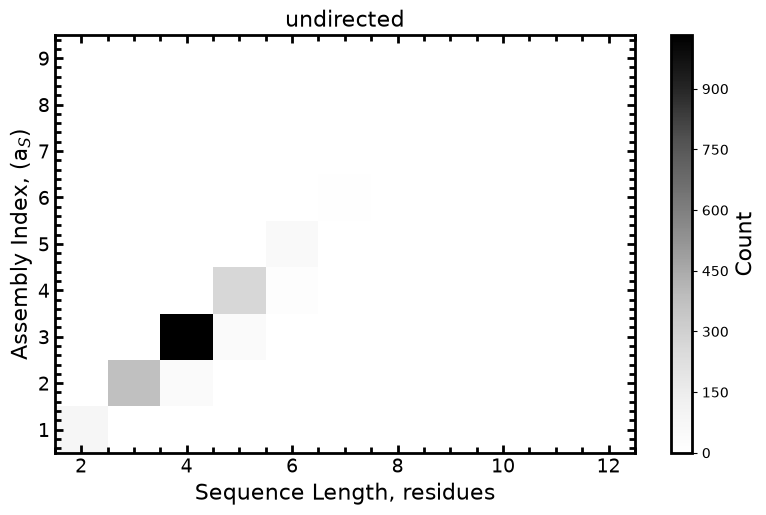

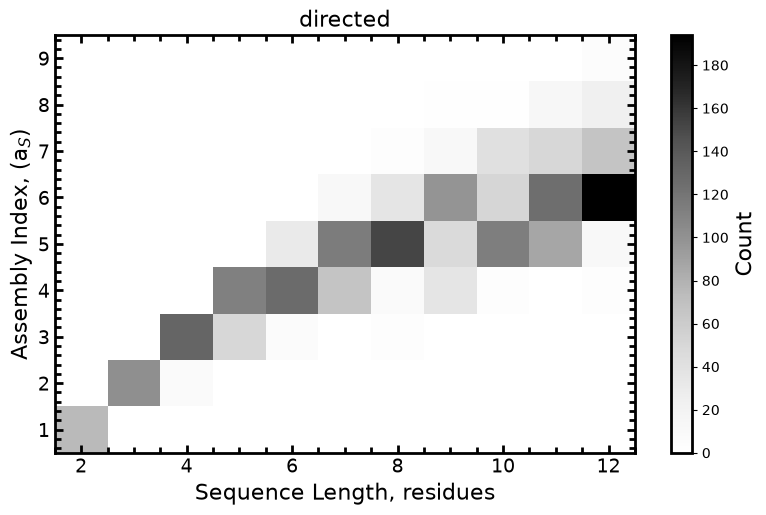

In [16]:
lengths = {regime: np.array([len(s) for counts in ensemble for s in counts])
           for regime, ensemble in ensembles.items()}
indices = {regime: np.array([index_of[s] for counts in ensemble for s in counts])
           for regime, ensemble in ensembles.items()}

x_edges = np.arange(1.5, MAX_LENGTH + 1.5, 1)
y_edges = np.arange(0.5, max(index_of.values()) + 1.5, 1)

for regime in order:
    fig, ax = att.plot_heatmap(
        lengths[regime], indices[regime],
        "Sequence Length, residues", "Assembly Index, (a$_S$)",
        nbins=(x_edges, y_edges), c_map='Greys',
    )
    ax.set_title(regime, fontsize=16)
    plt.savefig(f"length_vs_index_{regime}.png", dpi=300)
    plt.savefig(f"length_vs_index_{regime}.svg")
    plt.show()

*Assembly index against sequence length for the pooled runs of each regime, as in Figure 3e and 3g. Undirected exploration hugs the no-reuse diagonal; selection pushes the distribution to longer sequences whose indices fall well below it.*

The paper's other diagnostic compares independent runs against one another. If exploration is undirected, two runs agree on the simple sequences, which everything makes, and diverge on the complex ones, which are rare and reached by chance. If it is directed, the same preferences steer every run the same way, so agreement survives much further up the index.

Similarity is the intersection over union of the sequence sets of a pair of runs, taken separately in each assembly-index bin and averaged over all pairs.

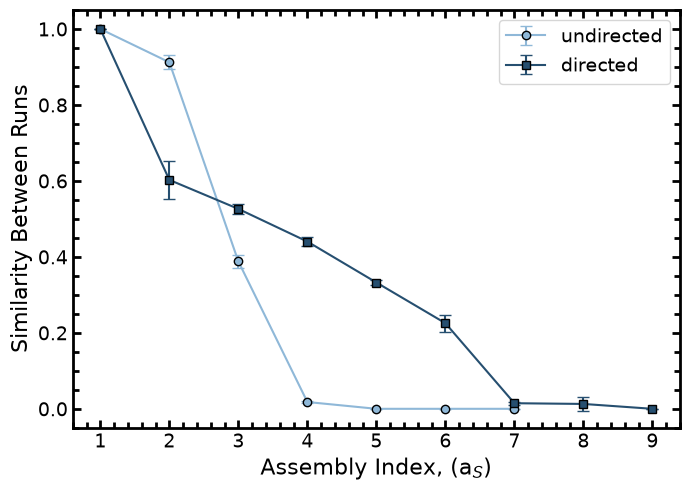

In [17]:
def run_similarity(ensemble):
    """Mean intersection-over-union between pairs of runs, per assembly index."""
    binned = [{} for _ in ensemble]
    for seen, counts in zip(binned, ensemble):
        for s in counts:
            seen.setdefault(index_of[s], set()).add(s)

    similarity = {}
    for a in sorted(set().union(*(set(seen) for seen in binned))):
        scores = []
        for first, second in itertools.combinations(binned, 2):
            x, y = first.get(a, set()), second.get(a, set())
            if x or y:
                scores.append(len(x & y) / len(x | y))
        if scores:
            similarity[a] = (float(np.mean(scores)), float(np.std(scores)))
    return similarity


fig, ax = plt.subplots(figsize=(7, 5))
for regime, marker, colour in zip(order, ('o', 's'), ('#8fb8d8', '#264f70')):
    similarity = run_similarity(ensembles[regime])
    xs = list(similarity)
    ys = [similarity[a][0] for a in xs]
    es = [similarity[a][1] for a in xs]
    ax.errorbar(xs, ys, yerr=es, marker=marker, capsize=4, color=colour,
                markeredgecolor='black', label=regime, zorder=3)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=14)
att.ax_plot(fig, ax, "Assembly Index, (a$_S$)", "Similarity Between Runs",
            xs=16, ys=16)
plt.savefig("run_similarity.png", dpi=300)
plt.savefig("run_similarity.svg")
plt.show()

*Mean intersection-over-union between independent runs, binned by assembly index, as in Figure 3d and 3f. Undirected runs stop agreeing as soon as the sequences get complex; directed runs keep agreeing, because the same preference steers all of them.*

## Part C: where the copy numbers come from

### 8. From abundance to copy number

Everything above used copy numbers the simulation knows exactly. A real experiment does not have them. The paper's ensembles were identified by LC-MS/MS, and mass spectrometry reports **intensity**, which is copy number multiplied by an ionisation response that varies by orders of magnitude between peptides and is not known. The paper's response is to discard intensity altogether and give every detected species the same effective copy number, on the grounds that all of them cleared the detection threshold.

That is a strong assumption. It can be tested here, because the simulation supplies a ground truth the experiment cannot: take the true copy numbers, multiply each by a random log-normal response factor to make a synthetic intensity, censor whatever falls below a detection floor, and then see which recipe for turning the surviving intensities back into $n_i$ recovers the true answer.

In [18]:
def detect(counts, sigma, rng):
    """Turn true copy numbers into observed intensities, censored at the floor."""
    seqs = list(counts)
    response = rng.lognormal(0.0, sigma, size=len(seqs))
    intensity = np.array([counts[s] for s in seqs], float) * response

    seen = intensity >= DETECTION_FLOOR
    return ([s for s, keep in zip(seqs, seen) if keep],
            np.array([counts[s] for s in seqs], float)[seen],
            intensity[seen])


def assembly_under_schemes(counts, sigma, rng):
    """Evaluate A on one ensemble under each way of assigning copy numbers."""
    seqs, true_n, intensity = detect(counts, sigma, rng)
    ai = [index_of[s] for s in seqs]
    n_t = true_n.sum()

    return {
        'true copy number': att.calculate_assembly_from_indices(ai, true_n),
        'equal per detection': att.calculate_assembly_from_indices(
            ai, np.full(len(ai), EQUAL_COPY_NUMBER)),
        'intensity-proportional': att.calculate_assembly_from_indices(
            ai, intensity / intensity.sum() * n_t),
        'log-scaled intensity': att.calculate_assembly_from_indices(
            ai, np.log1p(intensity) / np.log1p(intensity).sum() * n_t),
        'detected': len(seqs),
    }


rng = np.random.default_rng(RESPONSE_SEED)
schemes = pd.DataFrame([
    {'regime': regime, **assembly_under_schemes(ensembles[regime][0], RESPONSE_SIGMA, rng)}
    for regime in order
]).set_index('regime')

table = schemes.drop(columns='detected').T
table['directed / undirected'] = table['directed'] / table['undirected']
display(table.round(3))

undetected = {r: att.calculate_assembly_from_indices(
    [index_of[s] for s in ensembles[r][0]],
    list(ensembles[r][0].values())) for r in order}
print(f"Detected {schemes['detected'].to_dict()} of "
      f"{ {r: len(ensembles[r][0]) for r in order} } sequences.")
print(f"Before any detection at all the ratio is "
      f"{undetected['directed'] / undetected['undirected']:.2f}, against "
      f"{table.loc['true copy number', 'directed / undirected']:.2f} after it,")
print("so the threshold explains almost none of the shift the schemes show.")
print("The rest of it is the weighting.")

regime,undirected,directed,directed / undirected
true copy number,3.526,31.726,8.999
equal per detection,22.762,268.463,11.794
intensity-proportional,4.411,39.825,9.029
log-scaled intensity,15.197,180.542,11.880


Detected {'undirected': 409, 'directed': 437} of {'undirected': 638, 'directed': 683} sequences.
Before any detection at all the ratio is 8.89, against 9.00 after it,
so the threshold explains almost none of the shift the schemes show.
The rest of it is the weighting.


Every scheme puts the directed ensemble above the undirected one, so the paper's qualitative conclusion survives whichever is used, and all of them overstate the contrast to a similar degree. That is not the interesting part.

The interesting part is that an experimenter gets **one** draw of ionisation responses, and never learns what it was. So the question is not which scheme is closest on average, but how much the answer would have moved had the responses come out differently. Repeating the detection with independent response draws answers it directly.

In [19]:
%%time
def repeatability(sigma, n_draws):
    """Spread of A across independent draws of the ionisation responses."""
    values = {scheme: {regime: [] for regime in order} for scheme in SCHEMES}

    for draw in range(n_draws):
        rng = np.random.default_rng(RESPONSE_SEED + draw)
        for regime in order:
            for scheme, value in assembly_under_schemes(
                    ensembles[regime][0], sigma, rng).items():
                if scheme in values:
                    values[scheme][regime].append(value)

    return {
        scheme: {
            'A (directed)': float(np.mean(regimes['directed'])),
            'variation in A': float(np.std(regimes['directed'])
                                    / np.mean(regimes['directed'])),
            'variation in the ratio': float(
                np.std(np.array(regimes['directed'])
                       / np.array(regimes['undirected']))
                / np.mean(np.array(regimes['directed'])
                          / np.array(regimes['undirected']))),
        }
        for scheme, regimes in values.items()
    }


repeats = pd.DataFrame(repeatability(RESPONSE_SIGMA, N_DRAWS)).T
display(pd.DataFrame({
    'A (directed)': repeats['A (directed)'].round(1),
    'variation in A': (100 * repeats['variation in A']).round(1),
    'variation in the ratio': (100 * repeats['variation in the ratio']).round(1),
}).rename(columns={'variation in A': 'variation in A, %',
                   'variation in the ratio': 'variation in the ratio, %'}))

,A (directed),"variation in A, %","variation in the ratio, %"
true copy number,31.6,1.3,1.4
equal per detection,282.2,6.5,10.0
intensity-proportional,48.2,20.1,22.0
log-scaled intensity,189.7,6.9,10.0


CPU times: user 76.2 ms, sys: 977 μs, total: 77.2 ms
Wall time: 77 ms


Reading down the first column: the true copy numbers move by a percent or so between draws, which is only the detection threshold letting a slightly different set of species through. Giving every detection the same copy number tracks that closely, because it never reads an intensity — the responses reach it solely through which species were detected. Weighting by intensity does not: the same ensemble, measured twice, gives answers tens of percent apart.

That gap widens as responses become less comparable.

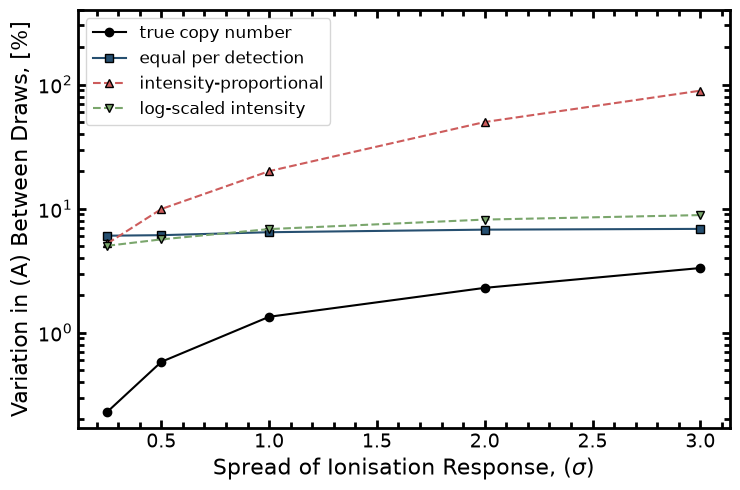

CPU times: user 650 ms, sys: 27.1 ms, total: 677 ms
Wall time: 676 ms


In [20]:
%%time
spread = pd.DataFrame([
    {'sigma': sigma, 'scheme': scheme, **stats}
    for sigma in RESPONSE_SIGMAS
    for scheme, stats in repeatability(sigma, N_DRAWS).items()
])

fig, ax = plt.subplots(figsize=(7.5, 5))
styles = {'true copy number': ('k', 'o', '-'),
          'equal per detection': ('#264f70', 's', '-'),
          'intensity-proportional': ('indianred', '^', '--'),
          'log-scaled intensity': ('#7aa66c', 'v', '--')}
for scheme, (colour, marker, line) in styles.items():
    subset = spread[spread['scheme'] == scheme]
    ax.plot(subset['sigma'], 100 * subset['variation in A'], line, marker=marker,
            color=colour, markeredgecolor='black', label=scheme, zorder=3)
ax.set_yscale('log')
ax.set_ylim(top=400)
ax.legend(fontsize=12, loc='upper left')
att.ax_plot(fig, ax, r"Spread of Ionisation Response, ($\sigma$)",
            "Variation in (A) Between Draws, [%]", xs=16, ys=16)
plt.savefig("copy_number_schemes.png", dpi=300)
plt.savefig("copy_number_schemes.svg")
plt.show()

*How reproducible each way of assigning copy numbers is, as ionisation efficiencies become less comparable. Each point is the spread of the directed ensemble's assembly over independent draws of the response factors. Weighting by intensity inherits the variation; giving every detection the same copy number does not, because it never reads the intensities at all.*

In [21]:
worst = spread[spread['sigma'] == max(RESPONSE_SIGMAS)].set_index('scheme')
print(f"At sigma = {max(RESPONSE_SIGMAS)}, A varies between draws by:")
for scheme in SCHEMES:
    print(f"    {scheme:24} {worst.loc[scheme, 'variation in A']:6.1%}")
print()
print("Reading the two results together:")
print()
print("  * Assigning every detection the same copy number is the reproducible")
print("    choice. It ignores intensity, so the unknown response factors reach")
print("    it only through which species cleared the detection floor. That is")
print("    the paper's justification, and it holds.")
print()
print("  * Reproducible is not the same as right. Every scheme, this one")
print("    included, overstates the contrast between the two ensembles,")
print("    because discarding intensity also discards the damping that real")
print("    copy numbers apply to rare, complex sequences.")
print()
print("  * So read A as a comparison between ensembles measured the same way,")
print("    never as a quantity with an absolute value.")

At sigma = 3.0, A varies between draws by:
    true copy number           3.3%
    equal per detection        6.9%
    intensity-proportional    89.5%
    log-scaled intensity       8.9%

Reading the two results together:

  * Assigning every detection the same copy number is the reproducible
    choice. It ignores intensity, so the unknown response factors reach
    it only through which species cleared the detection floor. That is
    the paper's justification, and it holds.

  * Reproducible is not the same as right. Every scheme, this one
    included, overstates the contrast between the two ensembles,
    because discarding intensity also discards the damping that real
    copy numbers apply to rare, complex sequences.

  * So read A as a comparison between ensembles measured the same way,
    never as a quantity with an absolute value.


### 9. Using your own data

Nothing above depends on the sequences having come from a simulation. To run this on your own peptides you need a sequence and a copy number for each, and the copy numbers are yours to justify — the previous section is about what that choice costs.

If what you have is a list of observations with repeats, `att.count_copies` collapses it into the two aligned lists the assembly equation wants.

In [22]:
observations = ['GGAP', 'AVGP', 'GGAP', 'HHPV', 'GGAP', 'AVGP', 'GGGAPP']

observed_sequences, observed_counts = att.count_copies(observations)
print(dict(zip(observed_sequences, observed_counts)))

{'GGAP': 3, 'AVGP': 2, 'HHPV': 1, 'GGGAPP': 1}


If instead you have a table, build a DataFrame with a sequence column and a copy-number column. Rows that name the same sequence — two mass-spectrometry features assigned the same peptide, say — have to be summed first, because the equation counts each unique object once.

In [23]:
my_data = pd.DataFrame({
    'sequence': ['GGAP', 'AVGP', 'GGAP', 'HHPV', 'GGGAPP', 'AVGP', 'GVHP'],
    'copy_number': [120, 45, 80, 3, 12, 30, 1],
})
# my_data = pd.read_csv("my_peptides.csv")   # any table with those two columns

my_data = my_data.groupby('sequence', as_index=False)['copy_number'].sum()
my_data['a_S'] = [att.calculate_string_assembly_index(s.lower(), mode='str')[0]
                  for s in my_data['sequence']]
my_data['a_P'] = my_data['a_S'] + a_jas
display(my_data)

,sequence,copy_number,a_S,a_P
0,AVGP,75,3,15
1,GGAP,200,3,15
2,GGGAPP,12,5,17
3,GVHP,1,3,15
4,HHPV,3,3,15


In [24]:
my_pathways = [att.calculate_string_assembly_index(s.lower(), mode='cfg')[2]
               for s in my_data['sequence']]

print(f"Unique sequences:   {len(my_data)}")
print(f"Total copy number:  {my_data['copy_number'].sum()}")
print(f"Exploration ratio:  "
      f"{att.exploration_ratio(my_pathways, observed=my_data['sequence'].str.lower()):.3f}")
print(f"A on the sequence scale: "
      f"{att.calculate_assembly_from_indices(my_data['a_S'], my_data['copy_number']):.3f}")
print(f"A on the peptide scale:  "
      f"{att.calculate_assembly_from_indices(my_data['a_P'], my_data['copy_number']):.3e}")
print()
print("GVHP has a single copy, so it contributes nothing to A whatever its")
print("index. The exploration ratio is low for a reason that has nothing to do")
print("with selection: five unrelated sequences share almost no intermediates,")
print("so their joint assembly space is nearly all contingent. The ratio only")
print("means something for an ensemble large enough to be built out of itself.")

Unique sequences:   5
Total copy number:  291
Exploration ratio:  0.238
A on the sequence scale: 24.591
A on the peptide scale:  4.002e+06

GVHP has a single copy, so it contributes nothing to A whatever its
index. The exploration ratio is low for a reason that has nothing to do
with selection: five unrelated sequences share almost no intermediates,
so their joint assembly space is nearly all contingent. The ratio only
means something for an ensemble large enough to be built out of itself.


In [25]:
print(f"Total wall time: {time.perf_counter() - _t_start:.1f} s")

Total wall time: 7.8 s


## Related documentation

* [Assembly theory](https://assemblytheorytools.readthedocs.io/en/latest/theory.html) — copy number, the assembly equation and the exploration ratio.
* [Strings guide](https://assemblytheorytools.readthedocs.io/en/latest/guide/strings.html) — sequence assembly indices and the backends behind them.
* [Route map](https://assemblytheorytools.readthedocs.io/en/latest/route_map.html) — the ensemble quantities used here, and everything they sit beside.